# 225. Implement Stack using Queues
https://leetcode.com/problems/implement-stack-using-queues/

## Complexity Comparison

| Approach | Push | Pop | Top | Notes |
|----------|------|-----|-----|-------|
| One queue (push costly) | $O(n)$ | $O(1)$ | $O(1)$ | Rotate after push |
| Two queues | $O(n)$ or $O(1)$ | $O(1)$ or $O(n)$ | $O(1)$ | Move elements between queues |

## Methodology

Use a single queue. On push, enqueue the element then dequeue and re-enqueue all previous elements. This makes the front of the queue always hold the most recently pushed element (stack top). Pop and top are O(1) since the front is the stack top.

## Solutions

### C#

In [ ]:
public class MyStack {
    private Queue<int> queue = new Queue<int>();

    public void Push(int x) {
        queue.Enqueue(x);
        for (int i = 0; i < queue.Count - 1; i++)
            queue.Enqueue(queue.Dequeue());
    }

    public int Pop() => queue.Dequeue();
    public int Top() => queue.Peek();
    public bool Empty() => queue.Count == 0;
}

### Python

In [ ]:
from collections import deque

class MyStack:
    def __init__(self):
        self.q = deque()

    def push(self, x: int) -> None:
        self.q.append(x)
        for _ in range(len(self.q) - 1):
            self.q.append(self.q.popleft())

    def pop(self) -> int:
        return self.q.popleft()

    def top(self) -> int:
        return self.q[0]

    def empty(self) -> bool:
        return len(self.q) == 0

### Go

In [ ]:
type MyStack struct {
    q []int
}

func Constructor() MyStack {
    return MyStack{}
}

func (s *MyStack) Push(x int) {
    s.q = append(s.q, x)
    for i := 0; i < len(s.q)-1; i++ {
        s.q = append(s.q, s.q[0])
        s.q = s.q[1:]
    }
}

func (s *MyStack) Pop() int {
    val := s.q[0]
    s.q = s.q[1:]
    return val
}

func (s *MyStack) Top() int {
    return s.q[0]
}

func (s *MyStack) Empty() bool {
    return len(s.q) == 0
}

### Rust

In [ ]:
use std::collections::VecDeque;

struct MyStack {
    q: VecDeque<i32>,
}

impl MyStack {
    fn new() -> Self {
        MyStack { q: VecDeque::new() }
    }

    fn push(&mut self, x: i32) {
        self.q.push_back(x);
        for _ in 0..self.q.len() - 1 {
            let val = self.q.pop_front().unwrap();
            self.q.push_back(val);
        }
    }

    fn pop(&mut self) -> i32 {
        self.q.pop_front().unwrap()
    }

    fn top(&self) -> i32 {
        *self.q.front().unwrap()
    }

    fn empty(&self) -> bool {
        self.q.is_empty()
    }
}

## Example Scenarios

### 1. Common Case — Push and Top
**Input:** `push(1), push(2), top()`

After push(1), queue = [1]. For push(2): enqueue 2 giving [1,2], then rotate 1 element (dequeue 1, re-enqueue) giving [2,1]. Now the front is 2, which is the stack top. `top()` peeks the front = 2.

WHY tricky: The key insight is **rotating after every push** so the front always holds the stack's top. This makes push $O(n)$ but top/pop $O(1)$.

Push rotates $n-1 = 1$ element. Queue front = stack top. **Output:** `top() = 2`

---

### 2. Slightly Complex — Interleaved Push and Pop
**Input:** `push(1), push(2), pop(), push(3), pop(), pop()`

After push(1), push(2): queue = [2,1]. pop() returns 2, queue = [1]. push(3) and rotate: queue = [3,1]. pop() returns 3, queue = [1]. pop() returns 1, queue = []. LIFO order maintained.

WHY tricky: Mixing push and pop means the **rotation count varies**. After pop reduces the queue size, the next push rotates fewer elements. LIFO order must hold regardless.

Each push(x) rotates $|\text{queue}| - 1$ elements. Returns: 2, 3, 1 (LIFO order). **Output:** `2, 3, 1`

---

### 3. Edge Case: Time — 100 Consecutive Pushes
**Input:** `push(1), push(2), push(3), ..., push(100)`

Each push(k) requires $k-1$ rotations. The total cost is $0+1+2+\ldots+99 = \frac{n(n-1)}{2} = 4{,}950$ dequeue/enqueue operations. This is the worst-case sequence for time.

WHY tricky: Push is $O(n)$ per operation. A sequence of $n$ pushes costs $O(n^2)$ total. This is the inherent **trade-off** for $O(1)$ pop/top using a single queue.

$\sum_{k=1}^{n} (k-1) = \frac{n(n-1)}{2} = \frac{100 \times 99}{2} = 4{,}950$ rotations. **Output:** Queue = `[100, 99, ..., 1]`

---

### 4. Edge Case: Space — Push Then Immediately Pop
**Input:** `push(5), pop(), push(10), pop(), push(15), pop()`

Each push is immediately followed by a pop. The queue never holds more than 1 element, so **no rotation** is needed ($n-1 = 0$). Space usage is $O(1)$ throughout.

WHY tricky: Best case for space — the push operation does zero rotations when the queue has 1 element. Each push-pop pair is $O(1)$ total, not the usual $O(n)$ push cost.

Max queue size $= 1$. Rotations per push $= 0$. **Output:** Returns `5, 10, 15`

---

### 5. Almost Impossible — 200 Mixed Operations
**Input:** `push(1)..push(100), pop()x50, push(101)..push(150), pop()x100`

First, 100 pushes build a queue of size 100 with total rotation cost 4,950. Then 50 pops ($O(1)$ each) drain half. Then 50 more pushes, each rotating $50+k$ elements. Finally 100 pops drain everything. Queue size oscillates between 0 and 100.

WHY tricky: Mixed operation sequences stress-test both the rotation logic and LIFO ordering. Peak queue size is 100 (which is the problem constraint). Total push cost is $O(n^2) \approx 7{,}425$ rotations.

Peak space: $O(100)$. Total push cost: $O(n^2)$. All 150 pops return correct LIFO order. **Output:** Correct LIFO sequence

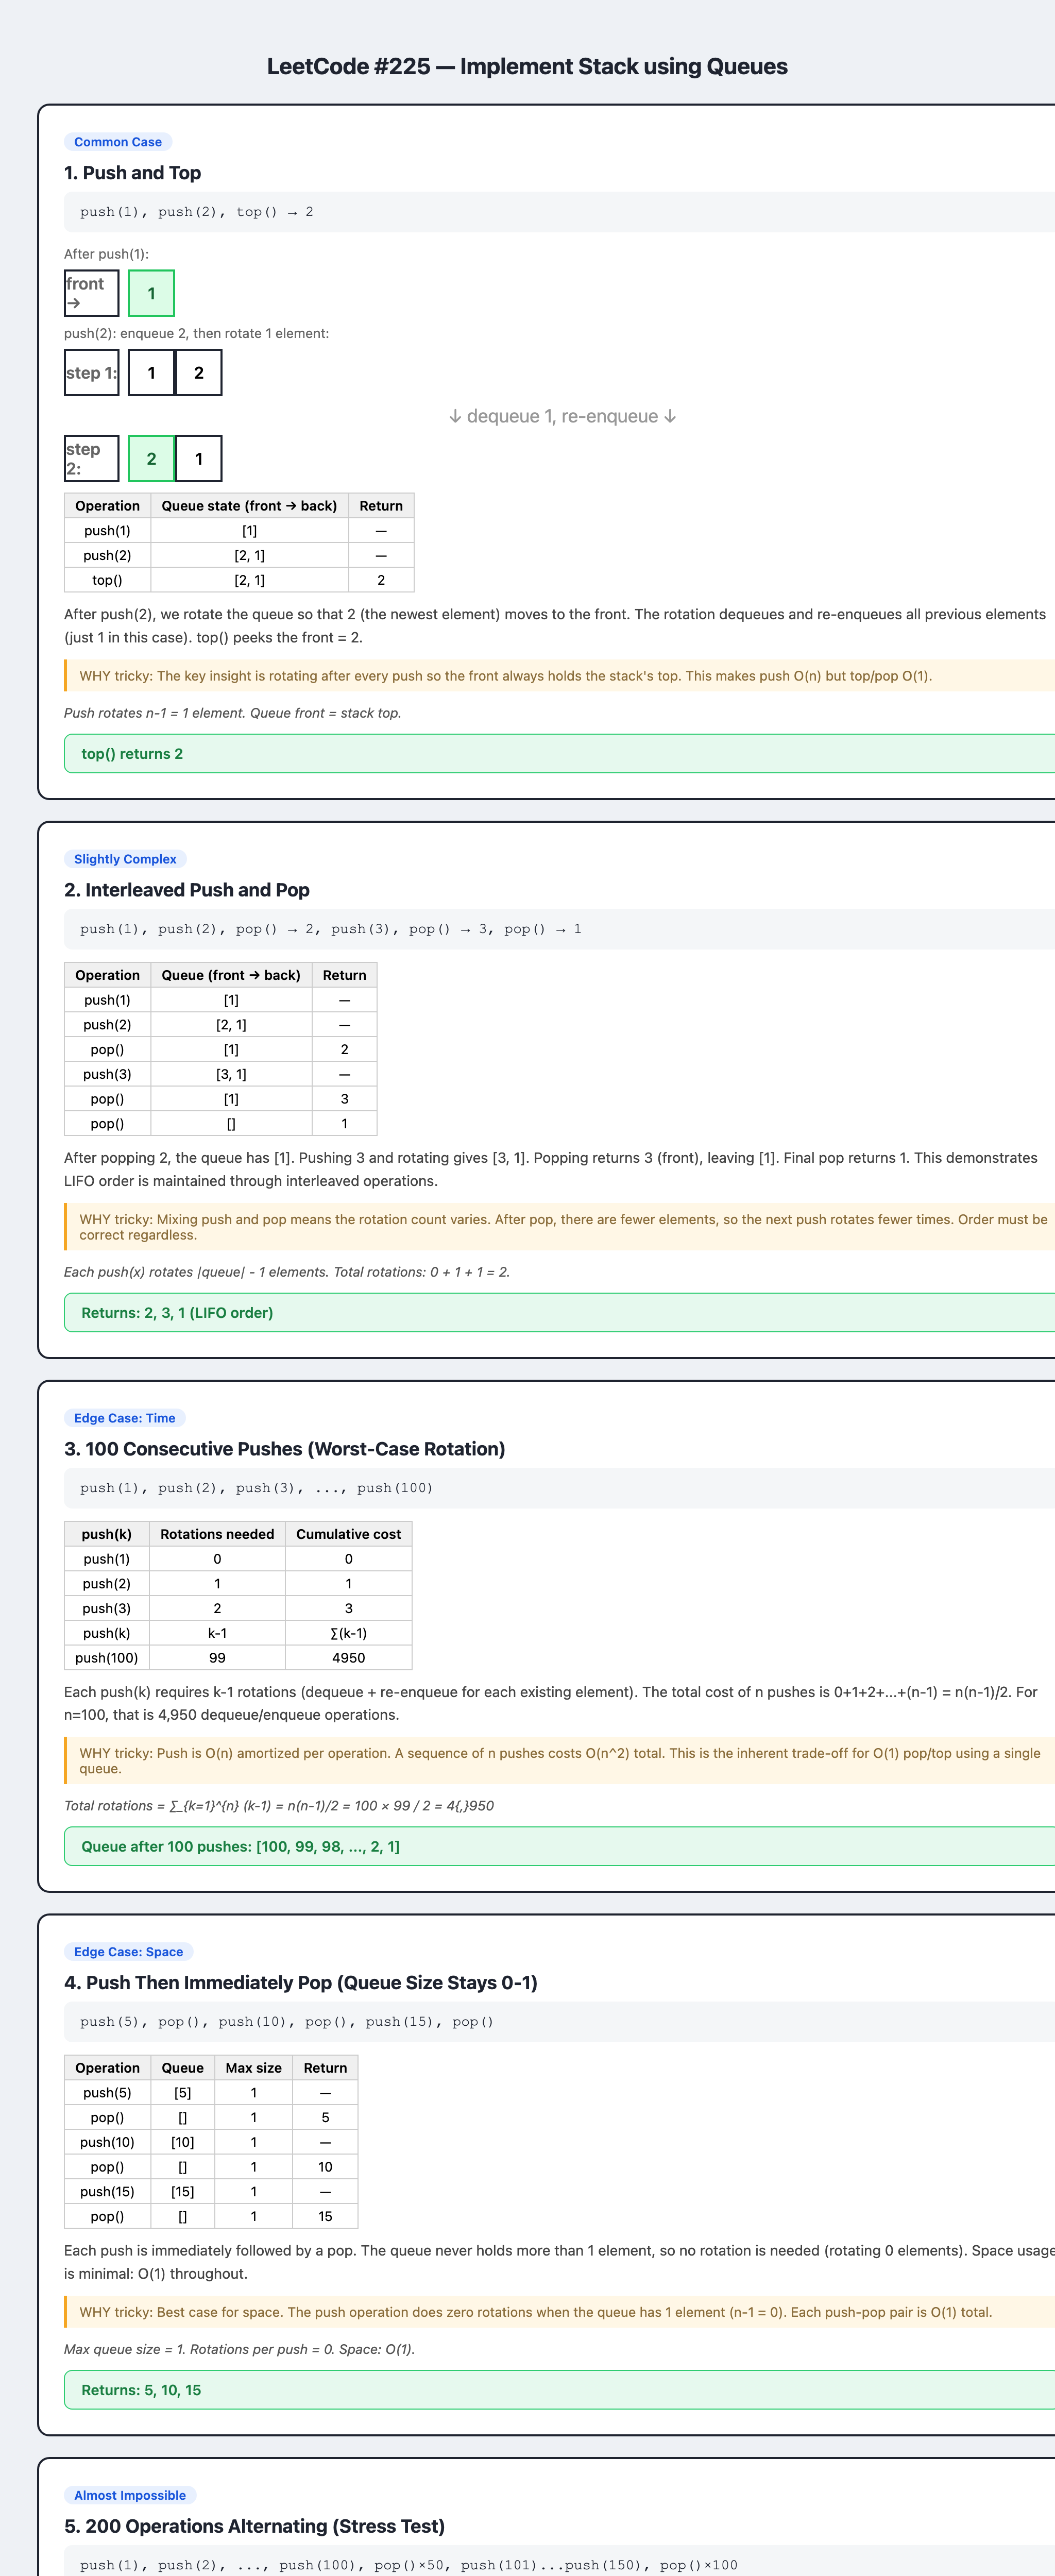